In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Load House 1.csv to Load House 1.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
file_path = "Load House 1.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (111068, 6)


,Date,Hour,Day of the Week,Season,Daytime,Consumption (kW)
0,2021-03-01,00:00:00,0,1,0,0.096
1,2021-03-01,00:15:00,0,1,0,0.196
2,2021-03-01,00:30:00,0,1,0,0.128
3,2021-03-01,00:45:00,0,1,0,0.156
4,2021-03-01,01:00:00,0,1,0,0.096


In [ ]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Hour"])

df = df.sort_values("datetime").reset_index(drop=True)

print(df.head())
print(df.info())

         Date      Hour  Day of the Week  Season  Daytime  Consumption (kW)  \
0  2021-03-01  00:00:00                0       1        0             0.096   
1  2021-03-01  00:15:00                0       1        0             0.196   
2  2021-03-01  00:30:00                0       1        0             0.128   
3  2021-03-01  00:45:00                0       1        0             0.156   
4  2021-03-01  01:00:00                0       1        0             0.096   

             datetime  
0 2021-03-01 00:00:00  
1 2021-03-01 00:15:00  
2 2021-03-01 00:30:00  
3 2021-03-01 00:45:00  
4 2021-03-01 01:00:00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111068 entries, 0 to 111067
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              111068 non-null  object        
 1   Hour              111068 non-null  object        
 2   Day of the Week   111068 non-null  int64      

In [ ]:
data = df[["datetime", "Consumption (kW)"]].copy()
data.rename(columns={"Consumption (kW)": "consumption"}, inplace=True)

print(data.head())
print(data.isnull().sum())

             datetime  consumption
0 2021-03-01 00:00:00        0.096
1 2021-03-01 00:15:00        0.196
2 2021-03-01 00:30:00        0.128
3 2021-03-01 00:45:00        0.156
4 2021-03-01 01:00:00        0.096
datetime       0
consumption    0
dtype: int64


In [ ]:
data = data.groupby("datetime", as_index=False)["consumption"].mean()

full_time = pd.date_range(
    start=data["datetime"].min(),
    end=data["datetime"].max(),
    freq="15min"
)

data = data.set_index("datetime").reindex(full_time)
data.index.name = "datetime"

data["consumption"] = data["consumption"].interpolate(method="time")
data["consumption"] = data["consumption"].ffill().bfill()

data = data.reset_index()

print("Cleaned shape:", data.shape)
print(data.isnull().sum())

print("\nTime gap check:")
print(data["datetime"].diff().value_counts().head())

Cleaned shape: (111073, 2)
datetime       0
consumption    0
dtype: int64

Time gap check:
datetime
0 days 00:15:00    111072
Name: count, dtype: int64


In [ ]:
hourly_data = data.copy()
hourly_data = hourly_data.set_index("datetime")

hourly_data = hourly_data.resample("1H").mean()

hourly_data = hourly_data.interpolate(method="time")
hourly_data = hourly_data.ffill().bfill()

hourly_data = hourly_data.reset_index()

print("Hourly shape:", hourly_data.shape)
print(hourly_data.head())

print("\nHourly gap check:")
print(hourly_data["datetime"].diff().value_counts().head())

Hourly shape: (27769, 2)
             datetime  consumption
0 2021-03-01 00:00:00        0.144
1 2021-03-01 01:00:00        0.075
2 2021-03-01 02:00:00        0.126
3 2021-03-01 03:00:00        0.063
4 2021-03-01 04:00:00        0.082

Hourly gap check:
datetime
0 days 01:00:00    27768
Name: count, dtype: int64


/tmp/ipykernel_1486/3212782757.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = hourly_data.resample("1H").mean()


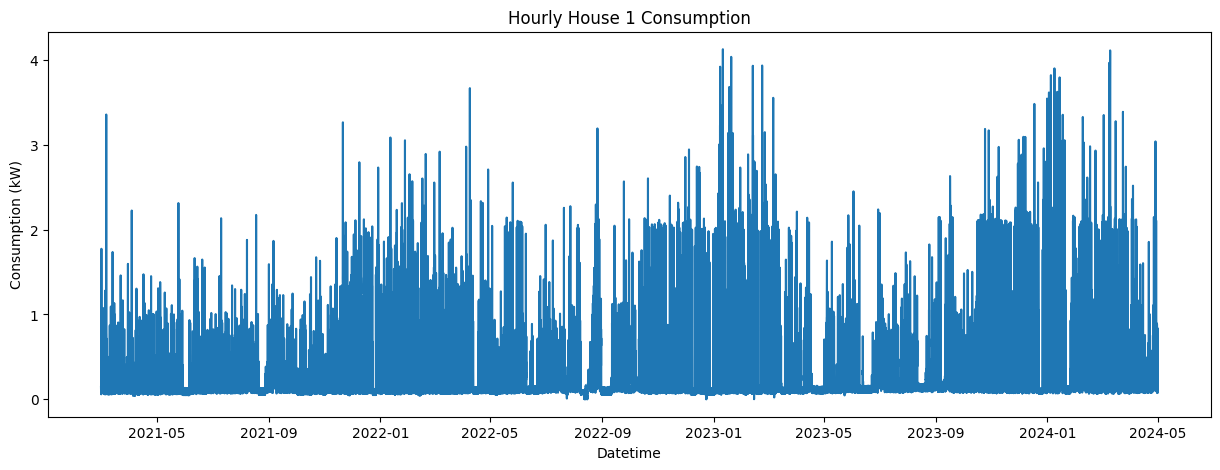

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(hourly_data["datetime"], hourly_data["consumption"])
plt.title("Hourly House 1 Consumption")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.show()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len):
        self.arr = arr.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.arr) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.arr[idx : idx + self.seq_len]
        y = self.arr[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.tensor(x), torch.tensor(y)


def prepare_loaders(hourly_data, seq_len=24, pred_len=1, batch_size=64):
    n = len(hourly_data)

    train_size = int(n * 0.7)
    val_size = int(n * 0.15)

    train_df = hourly_data.iloc[:train_size].copy()
    val_df = hourly_data.iloc[train_size:train_size + val_size].copy()
    test_df = hourly_data.iloc[train_size + val_size:].copy()

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train_df[["consumption"]])
    val_scaled = scaler.transform(val_df[["consumption"]])
    test_scaled = scaler.transform(test_df[["consumption"]])

    train_ds = TimeSeriesDataset(train_scaled, seq_len, pred_len)
    val_ds = TimeSeriesDataset(val_scaled, seq_len, pred_len)
    test_ds = TimeSeriesDataset(test_scaled, seq_len, pred_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler

In [ ]:
class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg = nn.AvgPool1d(
            kernel_size=kernel_size,
            stride=1,
            padding=kernel_size // 2
        )

    def forward(self, x):
        # x: [batch, seq_len, channels]
        x_perm = x.permute(0, 2, 1)
        trend = self.avg(x_perm)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend


class Autoformer(nn.Module):
    def __init__(
        self,
        seq_len=24,
        pred_len=1,
        d_model=64,
        n_heads=4,
        e_layers=3,
        dropout=0.1,
        kernel_size=3
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len

        self.decomp = SeriesDecomp(kernel_size)

        self.seasonal_embed = nn.Linear(1, d_model)
        self.trend_embed = nn.Linear(1, d_model)

        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            enc_layer,
            num_layers=e_layers
        )

        self.seasonal_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * d_model, pred_len)
        )

        self.trend_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * d_model, pred_len)
        )

    def forward(self, x):
        # x: [batch, seq_len, 1]

        seasonal, trend = self.decomp(x)

        seasonal = self.seasonal_embed(seasonal)
        trend = self.trend_embed(trend)

        seasonal = seasonal + self.pos_embed
        trend = trend + self.pos_embed

        seasonal_out = self.encoder(seasonal)
        trend_out = self.encoder(trend)

        seasonal_pred = self.seasonal_head(seasonal_out)
        trend_pred = self.trend_head(trend_out)

        out = seasonal_pred + trend_pred

        return out.unsqueeze(-1)

In [ ]:
loss_fn = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = loss_fn(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = loss_fn(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)


def test_model(model, loader, scaler, device):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)

            all_preds.append(out.cpu().numpy())
            all_true.append(y.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    pred_flat = all_preds.reshape(-1, 1)
    true_flat = all_true.reshape(-1, 1)

    pred_inv = scaler.inverse_transform(pred_flat)
    true_inv = scaler.inverse_transform(true_flat)

    mae = mean_absolute_error(true_inv, pred_inv)
    mse = mean_squared_error(true_inv, pred_inv)

    return mae, mse, true_inv, pred_inv

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

seq_len = 24
batch_size = 64
epochs = 10

pred_lens = [1, 8, 16, 24]

autoformer_results = {}

for pred_len in pred_lens:
    print("\n" + "="*50)
    print(f"Training Autoformer for {pred_len} hour forecast")
    print("="*50)

    train_loader, val_loader, test_loader, scaler = prepare_loaders(
        hourly_data,
        seq_len=seq_len,
        pred_len=pred_len,
        batch_size=batch_size
    )

    model = Autoformer(
        seq_len=seq_len,
        pred_len=pred_len,
        d_model=64,
        n_heads=4,
        e_layers=3,
        dropout=0.1,
        kernel_size=3
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float("inf")
    best_model_path = f"best_autoformer_{pred_len}.pth"

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss = validate(model, val_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}"
        )

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    mae, mse, true_inv, pred_inv = test_model(
        model,
        test_loader,
        scaler,
        device
    )

    autoformer_results[pred_len] = {
        "MAE": mae,
        "MSE": mse,
        "true": true_inv,
        "pred": pred_inv,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

    print(f"\nAutoformer {pred_len} hour forecast")
    print("MAE:", mae)
    print("MSE:", mse)

Device: cpu

Training Autoformer for 1 hour forecast
Epoch [1/10] Train Loss: 0.710632 | Val Loss: 0.479477
Epoch [2/10] Train Loss: 0.528642 | Val Loss: 0.534120
Epoch [3/10] Train Loss: 0.510728 | Val Loss: 0.472076
Epoch [4/10] Train Loss: 0.491483 | Val Loss: 0.598806
Epoch [5/10] Train Loss: 0.480545 | Val Loss: 0.441613
Epoch [6/10] Train Loss: 0.475639 | Val Loss: 0.444358
Epoch [7/10] Train Loss: 0.463733 | Val Loss: 0.422293
Epoch [8/10] Train Loss: 0.459075 | Val Loss: 0.424214
Epoch [9/10] Train Loss: 0.462384 | Val Loss: 0.409223
Epoch [10/10] Train Loss: 0.450822 | Val Loss: 0.438263

Autoformer 1 hour forecast
MAE: 0.28786420822143555
MSE: 0.2031870037317276

Training Autoformer for 8 hour forecast
Epoch [1/10] Train Loss: 0.861441 | Val Loss: 0.586523
Epoch [2/10] Train Loss: 0.759752 | Val Loss: 0.599720
Epoch [3/10] Train Loss: 0.736283 | Val Loss: 0.597871
Epoch [4/10] Train Loss: 0.712750 | Val Loss: 0.565715
Epoch [5/10] Train Loss: 0.699111 | Val Loss: 0.568893
Epo

In [ ]:
autoformer_result_df = pd.DataFrame({
    "Model": ["Autoformer", "Autoformer", "Autoformer", "Autoformer"],
    "Forecast Type": [
        "Single-step 1 hour",
        "Multi-step 8 hours",
        "Multi-step 16 hours",
        "Multi-step 24 hours"
    ],
    "Prediction Length": [1, 8, 16, 24],
    "MAE": [autoformer_results[p]["MAE"] for p in [1, 8, 16, 24]],
    "MSE": [autoformer_results[p]["MSE"] for p in [1, 8, 16, 24]]
})

autoformer_result_df

,Model,Forecast Type,Prediction Length,MAE,MSE
0,Autoformer,Single-step 1 hour,1,0.287864,0.203187
1,Autoformer,Multi-step 8 hours,8,0.388144,0.341351
2,Autoformer,Multi-step 16 hours,16,0.399429,0.366184
3,Autoformer,Multi-step 24 hours,24,0.400078,0.370903


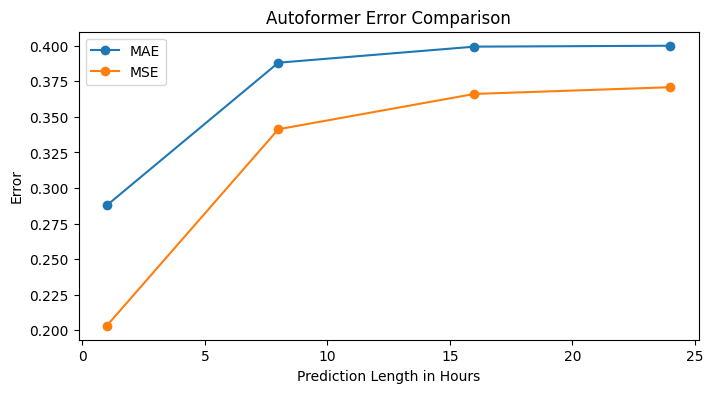

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    autoformer_result_df["Prediction Length"],
    autoformer_result_df["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    autoformer_result_df["Prediction Length"],
    autoformer_result_df["MSE"],
    marker="o",
    label="MSE"
)

plt.xlabel("Prediction Length in Hours")
plt.ylabel("Error")
plt.title("Autoformer Error Comparison")
plt.legend()
plt.show()